# Travelling Salesman Problem: Four Search Strategies, One Neighbourhood

**Module:** UFCEL1-15-M, AI for Search and Optimisation
**Instance:** 50-city Euclidean TSP (`cities.csv`)

This notebook implements and compares four search algorithms:

1. **Hill Climbing** with random restarts, which acts as the baseline
2. **Simulated Annealing**
3. **Tabu Search**
4. **Genetic Algorithm**

Every algorithm is written from first principles. No optimisation library is imported.

All four explore the search space through the **same 2-opt operator**. Holding the
neighbourhood constant means that any difference in performance can be attributed to the
search strategy itself rather than to a difference in how neighbours are generated.

**To run:** place `cities.csv` in the same folder as this notebook and execute the cells in
order. Requires `numpy`, `pandas`, `matplotlib`, `seaborn` and `scipy`.


## 0. Setup

In [24]:
# pip install numpy pandas matplotlib seaborn scipy

import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

RANDOM_SEED = 42
N_RUNS = 30                 # independent repeats per algorithm

ORDER = ['Hill Climbing', 'Simulated Annealing', 'Tabu Search', 'Genetic Algorithm']
PALETTE = dict(zip(ORDER, ['#4C72B0', '#DD8452', '#55A868', '#C44E52']))

## 1. Problem representation

The distance matrix is computed once and reused. This is not merely a speed optimisation:
it is what makes the constant-time move evaluation in Section 2 possible, and that in turn
is what allows all four algorithms to be compared on a like-for-like evaluation budget.

In [25]:
def load_cities(path="cities.csv"):
    """Read the city file and return an (n, 2) array of coordinates."""
    df = pd.read_csv(path)
    df.columns = [c.strip().lower() for c in df.columns]
    return df[["x", "y"]].to_numpy(dtype=float)


def distance_matrix(coords):
    """Full symmetric Euclidean distance matrix, computed once and reused.

    Pre-computing this is what makes the O(1) delta evaluation below possible.
    """
    n = len(coords)
    D = np.zeros((n, n), dtype=float)
    for i in range(n):
        for j in range(i + 1, n):
            dx = coords[i, 0] - coords[j, 0]
            dy = coords[i, 1] - coords[j, 1]
            d = math.sqrt(dx * dx + dy * dy)
            D[i, j] = d
            D[j, i] = d
    return D


def tour_length(route, D):
    """Total length of a closed tour. Note the wrap-around back to the start."""
    total = 0.0
    n = len(route)
    for i in range(n):
        total += D[route[i], route[(i + 1) % n]]
    return total


def random_route(n, rng):
    route = list(range(n))
    rng.shuffle(route)
    return route

In [26]:
CITIES_PATH = 'cities.csv'          # change if the file lives elsewhere

coords = load_cities(CITIES_PATH)
D = distance_matrix(coords)

print(f'Loaded {len(coords)} cities')
print(f'Distance matrix: {D.shape}, longest single hop {D.max():.2f}')
pd.read_csv(CITIES_PATH).head()

Loaded 50 cities
Distance matrix: (50, 50), longest single hop 120.62


,City,X,Y
0,City_1,37.454012,95.071431
1,City_2,73.199394,59.865848
2,City_3,15.601864,15.599452
3,City_4,5.808361,86.617615
4,City_5,60.111501,70.807258


## 2. The shared neighbourhood: 2-opt

A 2-opt move cuts two edges out of the tour and reconnects the endpoints the other way
round, which is equivalent to reversing the segment between them.

```
... a -> b ............ c -> d ...      becomes      ... a -> c ............ b -> d ...
```

Only two edges change. The effect on tour length can therefore be worked out without
re-measuring the whole tour:

$$\Delta = d(a,c) + d(b,d) - d(a,b) - d(c,d)$$

A negative $\Delta$ shortens the tour. This constant-time evaluation is used identically by
all four algorithms.

In [27]:
def two_opt_delta(route, i, j, D):
    """Cost change from reversing route[i:j+1]. O(1), no tour re-scan."""
    n = len(route)
    a, b = route[i - 1], route[i]
    c, d = route[j], route[(j + 1) % n]
    if a == c or b == d:
        return 0.0
    return (D[a, c] + D[b, d]) - (D[a, b] + D[c, d])


def two_opt_apply(route, i, j):
    """Return a new route with the segment route[i:j+1] reversed."""
    return route[:i] + route[i:j + 1][::-1] + route[j + 1:]


def two_opt_moves(n):
    """Every valid (i, j) 2-opt move for a tour of n cities."""
    return [(i, j) for i in range(1, n - 1) for j in range(i + 1, n)]

## 3. Hill Climbing with random restarts (baseline)

The climb never accepts a worse tour. It scans the whole neighbourhood, takes the single
best improving move, and halts when no improving move exists. Random restarts are its only
means of escaping a local optimum.

In [28]:
def hill_climbing(D, seed, restarts=20, max_iter=1000):
    """Steepest-ascent hill climbing.

    Each iteration scans the entire 2-opt neighbourhood and commits to the single
    best improving move. When no improving move exists the search is at a local
    optimum and stops. Random restarts are the only escape mechanism: the climb
    itself never accepts a worse solution.
    """
    rng = np.random.default_rng(seed)
    n = D.shape[0]
    moves = two_opt_moves(n)
    t0 = time.perf_counter()

    best_route, best_len = None, float("inf")
    history = []

    for _ in range(restarts):
        route = random_route(n, rng)
        length = tour_length(route, D)

        for _ in range(max_iter):
            best_delta, best_move = 0.0, None
            for (i, j) in moves:                    # scan the whole neighbourhood
                delta = two_opt_delta(route, i, j, D)
                if delta < best_delta - 1e-12:      # strictly improving
                    best_delta, best_move = delta, (i, j)
            if best_move is None:                   # local optimum reached
                break
            route = two_opt_apply(route, *best_move)
            length += best_delta

        if length < best_len:
            best_len, best_route = length, route
        history.append(best_len)

    return best_route, best_len, time.perf_counter() - t0, history

## 4. Simulated Annealing

One line separates this from hill climbing: a worsening move is accepted with probability
$e^{-\Delta/T}$. While $T$ is high the search roams almost freely. As $T$ decays
geometrically, tolerance for bad moves collapses and the search settles into refinement.

Parameters were selected by sweep (see Section 8): $T_0 = 100$, $\alpha = 0.9998$.

In [29]:
def simulated_annealing(D, seed, t_start=100.0, t_end=1e-3,
                        alpha=0.9998, iters_per_temp=12):
    """Metropolis acceptance with geometric cooling.

    The difference from hill climbing is one line: a worsening move is accepted
    with probability exp(-delta / T). Early on T is large and almost everything
    is accepted, so the search roams. As T decays the acceptance probability of
    bad moves collapses and the search hardens into a local refinement.
    """
    rng = np.random.default_rng(seed)
    n = D.shape[0]
    t0 = time.perf_counter()

    route = random_route(n, rng)
    length = tour_length(route, D)
    best_route, best_len = list(route), length

    T = t_start
    history = [length]

    while T > t_end:
        for _ in range(iters_per_temp):
            i = int(rng.integers(1, n - 1))
            j = int(rng.integers(i + 1, n))
            delta = two_opt_delta(route, i, j, D)

            if delta < 0 or rng.random() < math.exp(-delta / T):
                route = two_opt_apply(route, i, j)
                length += delta
                if length < best_len:
                    best_len, best_route = length, list(route)
        history.append(best_len)
        T *= alpha                                  # geometric cooling

    return best_route, best_len, time.perf_counter() - t0, history

## 5. Tabu Search

Tabu Search always takes the best available candidate move, **even when that move makes the
tour worse**. What prevents it from immediately undoing that move is the tabu list, which
forbids a recently used move for `tenure` iterations.

The aspiration criterion overrides the ban when a forbidden move would yield a new global
best, since refusing a record-breaking tour on a bookkeeping technicality would be
perverse.

In [30]:
def tabu_search(D, seed, iterations=1200, tenure=15, sample_size=260):
    """Best-of-neighbourhood with short-term memory.

    Tabu Search always moves to the best candidate available, even when that is
    worse than where it currently stands. What stops it looping straight back is
    the tabu list: a recently used move is forbidden for `tenure` iterations.
    The aspiration criterion overrides the ban if the move would produce a new
    global best, because there is no sense in refusing a record-breaking tour on
    a technicality.

    The neighbourhood is sampled rather than scanned in full, which keeps the
    per-iteration cost comparable to the other three algorithms.
    """
    rng = np.random.default_rng(seed)
    n = D.shape[0]
    all_moves = two_opt_moves(n)
    t0 = time.perf_counter()

    route = random_route(n, rng)
    length = tour_length(route, D)
    best_route, best_len = list(route), length

    tabu = {}                                       # move -> iteration it expires
    history = [length]

    for it in range(iterations):
        idx = rng.choice(len(all_moves), size=min(sample_size, len(all_moves)),
                         replace=False)
        cand_move, cand_delta = None, float("inf")

        for k in idx:
            i, j = all_moves[k]
            delta = two_opt_delta(route, i, j, D)
            is_tabu = tabu.get((i, j), 0) > it
            aspires = (length + delta) < best_len - 1e-12

            if is_tabu and not aspires:             # forbidden, and not special
                continue
            if delta < cand_delta:
                cand_move, cand_delta = (i, j), delta

        if cand_move is None:                       # everything was tabu
            continue

        route = two_opt_apply(route, *cand_move)
        length += cand_delta
        tabu[cand_move] = it + tenure               # serve your sentence

        if length < best_len:
            best_len, best_route = length, list(route)
        history.append(best_len)

    return best_route, best_len, time.perf_counter() - t0, history

## 6. Genetic Algorithm

A population-based method rather than a trajectory-based one. Three operators do the work:

| Operator | Choice | Reason |
|---|---|---|
| Selection | Tournament, $k=7$ | Strong pressure; $k=3$ was too permissive in the sweep |
| Crossover | Order Crossover (OX1) | Preserves relative city order and cannot create duplicates |
| Mutation | Inversion, rate 0.6 | Inversion **is** a 2-opt move, which keeps the GA in the same neighbourhood as the other three |

Elitism carries the best 5 individuals through untouched, so the best-so-far can never
regress.

In [31]:
def _tournament(pop_fit, k, rng):
    """Pick k individuals at random, return the index of the fittest."""
    contenders = rng.integers(0, len(pop_fit), size=k)
    winner = contenders[0]
    for c in contenders[1:]:
        if pop_fit[c] < pop_fit[winner]:
            winner = c
    return int(winner)


def _ox1(p1, p2, rng):
    """Order Crossover.

    Copy a random slice of parent 1 into the child, then fill the remaining
    slots with the cities of parent 2 in the order they appear there, skipping
    anything already present. This preserves relative city order from one parent
    and absolute position from the other, and can never produce a duplicate.
    """
    n = len(p1)
    a, b = sorted(rng.choice(n, size=2, replace=False))
    child = [-1] * n
    child[a:b + 1] = p1[a:b + 1]
    taken = set(child[a:b + 1])

    fill = [c for c in p2 if c not in taken]
    pos = 0
    for i in range(n):
        if child[i] == -1:
            child[i] = fill[pos]
            pos += 1
    return child


def _inversion_mutation(route, rate, rng):
    """Reverse a random segment. This is a 2-opt move applied blindly, which is
    what keeps the GA inside the same neighbourhood as the other three."""
    if rng.random() >= rate:
        return route
    n = len(route)
    i, j = sorted(rng.choice(n, size=2, replace=False))
    return two_opt_apply(route, i, j)


def genetic_algorithm(D, seed, pop_size=100, generations=260,
                      mutation_rate=0.6, tournament_k=7, elitism=5):
    """Generational GA with elitism.

    Tuned configuration: tournament size 7, elitism 5, inversion mutation, OX1.
    Fitness is cached per individual, so only new children are ever evaluated.
    """
    rng = np.random.default_rng(seed)
    n = D.shape[0]
    t0 = time.perf_counter()

    pop = [random_route(n, rng) for _ in range(pop_size)]
    fit = [tour_length(r, D) for r in pop]
    history = [min(fit)]

    for _ in range(generations):
        order = sorted(range(pop_size), key=lambda i: fit[i])
        new_pop = [list(pop[i]) for i in order[:elitism]]        # elites survive intact
        new_fit = [fit[i] for i in order[:elitism]]

        while len(new_pop) < pop_size:
            p1 = pop[_tournament(fit, tournament_k, rng)]
            p2 = pop[_tournament(fit, tournament_k, rng)]
            child = _ox1(p1, p2, rng)
            child = _inversion_mutation(child, mutation_rate, rng)
            new_pop.append(child)
            new_fit.append(tour_length(child, D))

        pop, fit = new_pop, new_fit
        history.append(min(fit))

    best_i = int(np.argmin(fit))
    return pop[best_i], fit[best_i], time.perf_counter() - t0, history

## 7. Experiment

Thirty independent runs per algorithm. Run $r$ uses seed $r$ for **all four** algorithms, so
the comparison is paired rather than a race between different random draws.

In [32]:
ALGORITHMS = {
    'Hill Climbing':       hill_climbing,
    'Simulated Annealing': simulated_annealing,
    'Tabu Search':         tabu_search,
    'Genetic Algorithm':   genetic_algorithm,
}

rows, curves, tours = [], {}, {}

for name, fn in ALGORITHMS.items():
    print(f'{name:<22}', end=' ', flush=True)
    for run in range(N_RUNS):
        route, length, secs, hist = fn(D, seed=RANDOM_SEED + run)
        assert sorted(route) == list(range(len(coords))), 'invalid tour!'
        rows.append({'algorithm': name, 'run': run, 'distance': length, 'time': secs})
        if run == 0:
            curves[name], tours[name] = hist, route
    print('done')

df = pd.DataFrame(rows)
df.head()

Hill Climbing          done
Simulated Annealing    done
Tabu Search            done
Genetic Algorithm      done


,algorithm,run,distance,time
0,Hill Climbing,0,570.416014,1.954051
1,Hill Climbing,1,559.864656,1.283579
2,Hill Climbing,2,559.864656,1.212660
3,Hill Climbing,3,563.023010,1.228801
4,Hill Climbing,4,578.680562,1.206605


## 8. Results

In [33]:
summary = (df.groupby('algorithm')
             .agg(mean_distance=('distance', 'mean'),
                  std_distance=('distance', 'std'),
                  best_distance=('distance', 'min'),
                  worst_distance=('distance', 'max'),
                  mean_time=('time', 'mean'))
             .round(3)
             .loc[ORDER])
summary

,mean_distance,std_distance,best_distance,worst_distance,mean_time
algorithm,,,,,
Hill Climbing,566.335,5.827,559.865,578.681,1.444
Simulated Annealing,571.412,5.638,559.865,585.820,5.471
Tabu Search,568.714,6.209,559.865,580.228,0.596
Genetic Algorithm,594.065,18.628,559.865,634.220,2.362


### 8.1 Distribution of tour lengths

The box plot is the important figure. A mean alone would hide the fact that the Genetic
Algorithm is not merely worse on average, it is *erratic*.

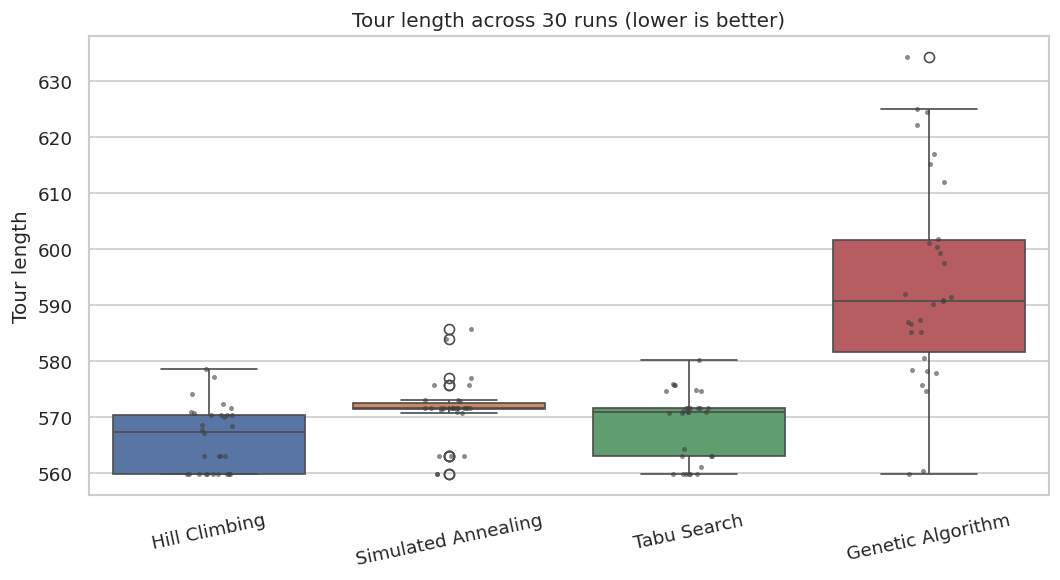

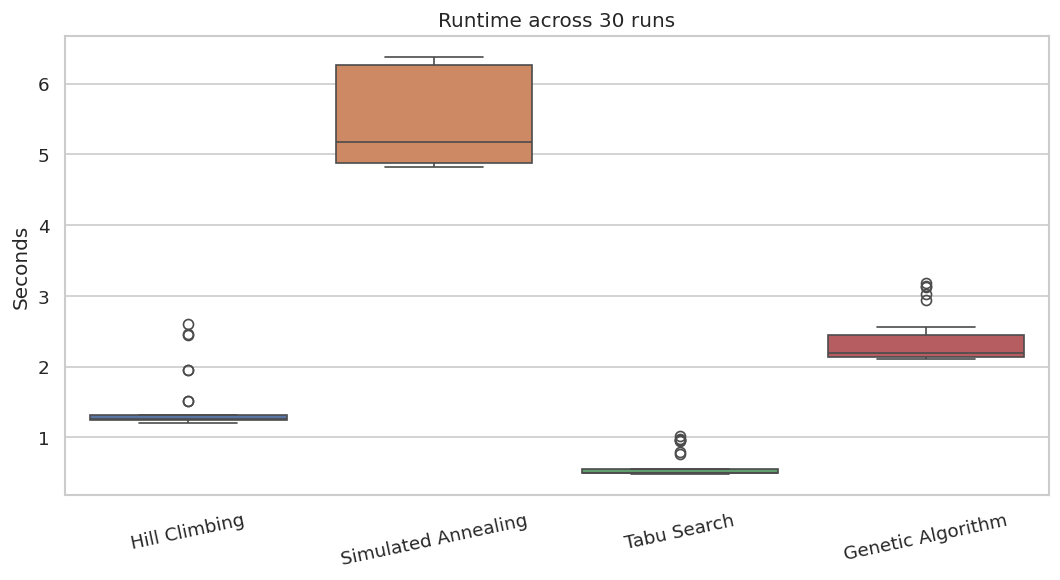

In [34]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='algorithm', y='distance', order=ORDER,
            hue='algorithm', palette=PALETTE, legend=False)
sns.stripplot(data=df, x='algorithm', y='distance', order=ORDER,
              color='0.25', size=3, alpha=0.6)
plt.title('Tour length across 30 runs (lower is better)')
plt.ylabel('Tour length'); plt.xlabel(''); plt.xticks(rotation=12)
plt.tight_layout(); plt.show()

plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='algorithm', y='time', order=ORDER,
            hue='algorithm', palette=PALETTE, legend=False)
plt.title('Runtime across 30 runs')
plt.ylabel('Seconds'); plt.xlabel(''); plt.xticks(rotation=12)
plt.tight_layout(); plt.show()

### 8.2 Convergence and the tours themselves

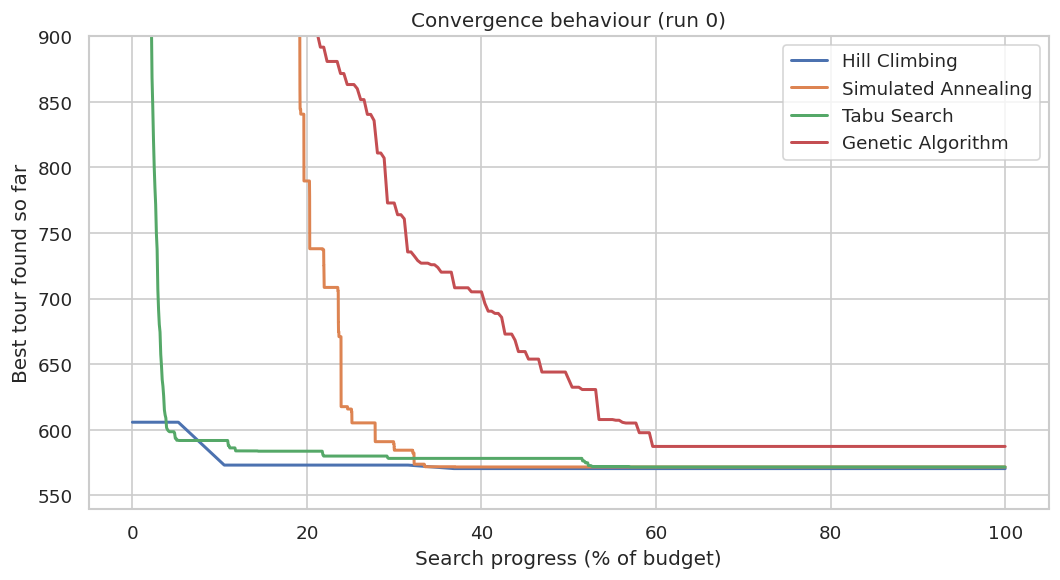

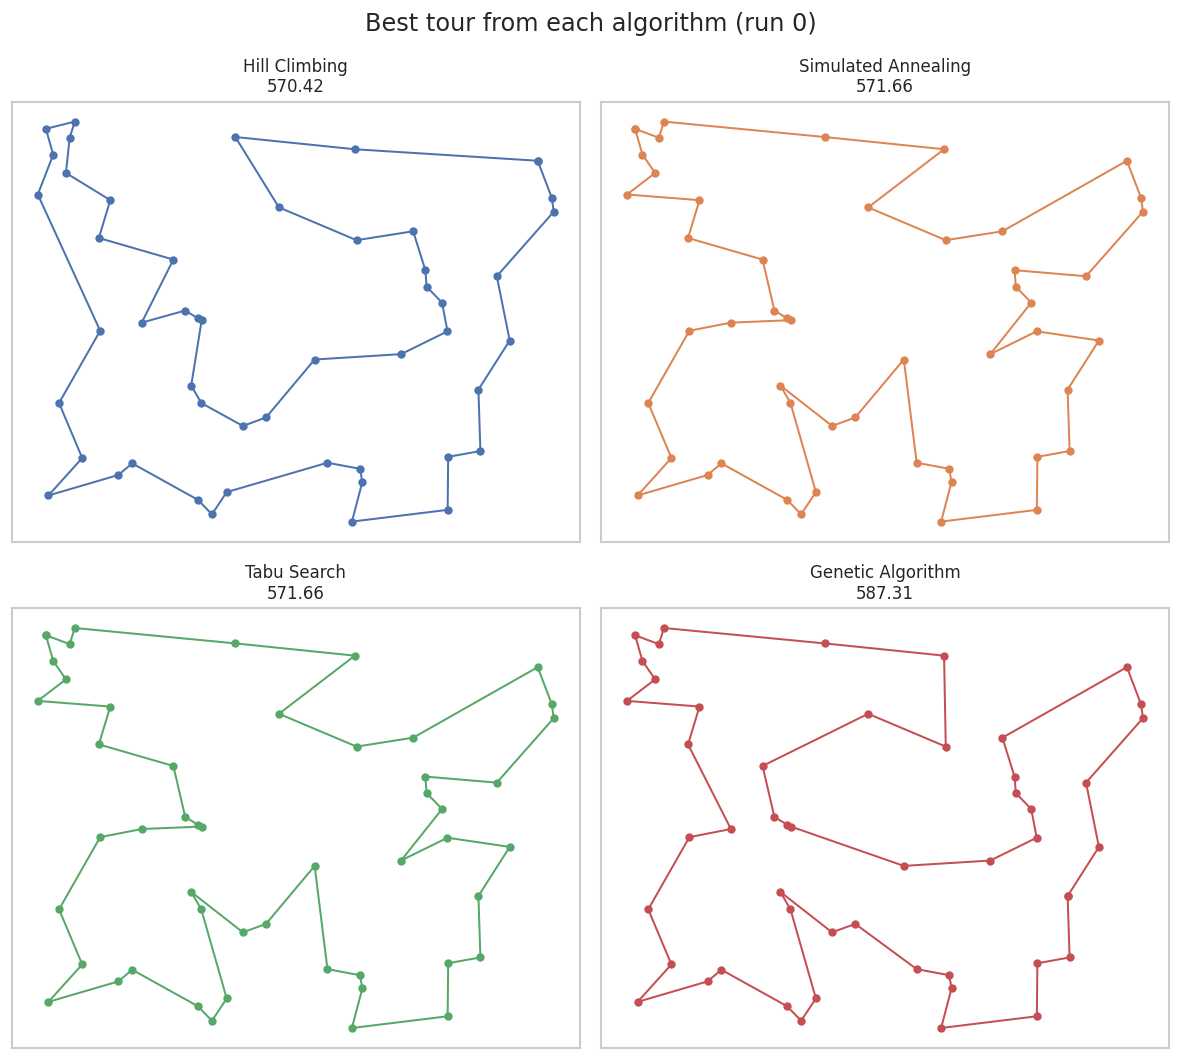

In [35]:
plt.figure(figsize=(9, 5))
for name in ORDER:
    h = curves[name]
    plt.plot(np.linspace(0, 100, len(h)), h, label=name, color=PALETTE[name], lw=1.8)
plt.xlabel('Search progress (% of budget)'); plt.ylabel('Best tour found so far')
plt.title('Convergence behaviour (run 0)'); plt.ylim(540, 900)
plt.legend(); plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for ax, name in zip(axes.ravel(), ORDER):
    r = tours[name] + [tours[name][0]]
    pts = coords[r]
    ax.plot(pts[:, 0], pts[:, 1], '-o', ms=4, lw=1.2, color=PALETTE[name])
    ax.set_title(f'{name}\n{tour_length(tours[name], D):.2f}', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Best tour from each algorithm (run 0)')
plt.tight_layout(); plt.show()

### 8.3 Quality against cost

Mean tour length on its own answers the wrong question. What a practitioner needs to know is
what each second of compute buys.

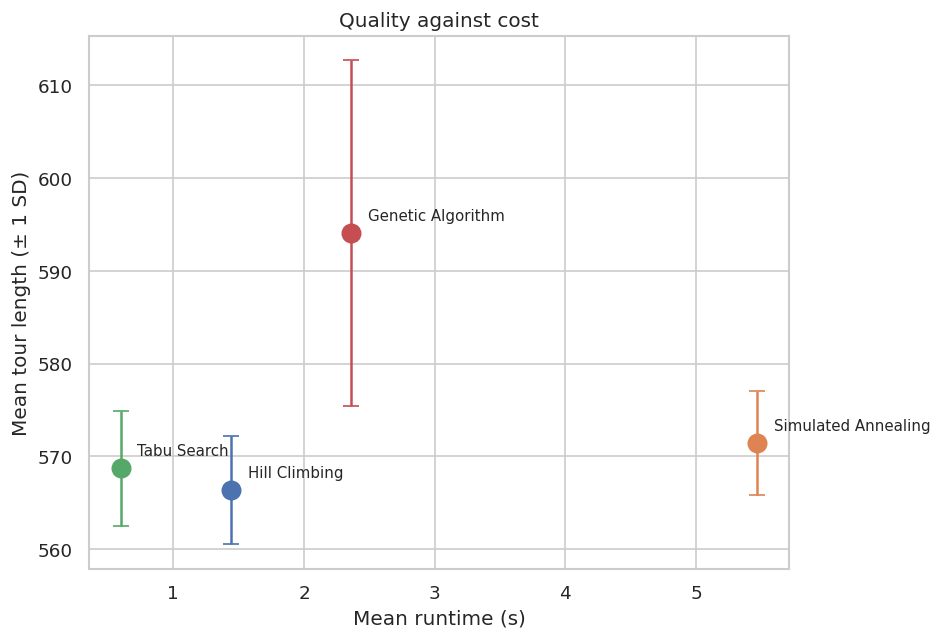

In [36]:
agg = df.groupby('algorithm').agg(m=('distance', 'mean'),
                                  s=('distance', 'std'),
                                  t=('time', 'mean')).loc[ORDER]
plt.figure(figsize=(8, 5.5))
for name in ORDER:
    plt.errorbar(agg.loc[name, 't'], agg.loc[name, 'm'], yerr=agg.loc[name, 's'],
                 fmt='o', ms=11, capsize=5, color=PALETTE[name])
    plt.annotate(name, (agg.loc[name, 't'], agg.loc[name, 'm']),
                 textcoords='offset points', xytext=(10, 8), fontsize=9)
plt.xlabel('Mean runtime (s)'); plt.ylabel('Mean tour length (± 1 SD)')
plt.title('Quality against cost')
plt.tight_layout(); plt.show()

## 9. Hypothesis testing

**H0:** the two algorithms draw tour lengths from populations with the same mean.
**H1:** the means differ.

Welch's t-test is used rather than Student's, because the variances are plainly unequal
(the GA's standard deviation is roughly three times that of the local search methods) and
Welch does not assume otherwise. Cohen's *d* is reported alongside *p*, because with enough
runs a trivial difference will still clear p < 0.05, and effect size is what says whether
the difference is worth anything.

In [ ]:
pairs = [('Hill Climbing', 'Simulated Annealing'),
         ('Hill Climbing', 'Tabu Search'),
         ('Hill Climbing', 'Genetic Algorithm'),
         ('Simulated Annealing', 'Tabu Search'),
         ('Simulated Annealing', 'Genetic Algorithm'),
         ('Tabu Search', 'Genetic Algorithm')]

get = lambda a: df[df.algorithm == a].distance.values

tests = []
for a, b in pairs:
    x, y = get(a), get(b)
    t_stat, p = stats.ttest_ind(x, y, equal_var=False)
    d = (x.mean() - y.mean()) / np.sqrt((x.var(ddof=1) + y.var(ddof=1)) / 2)
    tests.append({'comparison': f'{a} vs {b}',
                  't': round(t_stat, 3),
                  'p_value': f'{p:.2e}',
                  "cohen's d": round(d, 2),
                  'reject H0 at 0.05': 'Yes' if p < 0.05 else 'No'})

pd.DataFrame(tests)

### 9.1 Why 30 runs and not 10

Re-running the same tests on only the first 10 runs shows what an underpowered experiment
costs. The verdict does not flip, but it becomes fragile: Hill Climbing versus Simulated
Annealing clears the threshold only marginally at ten runs, and a single unlucky draw
would push it back over. Thirty runs turn a marginal call into a settled one.

In [38]:
for a, b in [('Hill Climbing', 'Simulated Annealing'),
             ('Simulated Annealing', 'Genetic Algorithm')]:
    x10 = df[(df.algorithm == a) & (df.run < 10)].distance.values
    y10 = df[(df.algorithm == b) & (df.run < 10)].distance.values
    _, p10 = stats.ttest_ind(x10, y10, equal_var=False)
    _, p30 = stats.ttest_ind(get(a), get(b), equal_var=False)
    print(f'{a:<20} vs {b:<20}  n=10: p={p10:.4f}   n=30: p={p30:.2e}')

Hill Climbing        vs Simulated Annealing   n=10: p=0.0385   n=30: p=1.12e-03
Simulated Annealing  vs Genetic Algorithm     n=10: p=0.0061   n=30: p=2.72e-07


## 10. Summary of findings

| Finding | Evidence |
|---|---|
| All four algorithms reach the same best tour, 559.87 | `best_distance` column, Section 8 |
| Hill Climbing and Tabu Search are statistically indistinguishable on quality | p = 0.132, Section 9 |
| Simulated Annealing is significantly *worse* than the plain baseline | p = 0.001, d = −0.89, Section 9 |
| Every local search method beats the GA, with a large effect | p < 1e-6, Cohen's d > 1.6 |
| Tabu Search is the best value | Matches Hill Climbing's quality in under 40% of its runtime |
| The GA's weakness is inconsistency, not incapability | It found 559.87 once, yet its SD is 18.6 against roughly 6 for the others |

The headline is that sophistication did not pay. The baseline was never beaten on quality,
and the recommendation turns on cost rather than cleverness. Simulated Annealing's failure
is a scale mismatch: at T₀ = 100 a worsening move of Δ = 5 is accepted with probability
exp(−0.05) ≈ 0.95, so the search spends most of its schedule accepting almost everything.
The initial temperature was never calibrated to the delta scale of this objective.